# NUS ST5202 / ST5202X — Applied Regression Analysis
## Tutor-style case study notebook using the scikit-learn Diabetes dataset

This notebook turns the main ideas of **Applied Regression Analysis** into one coherent case study.

Rather than treating regression as merely

$$
\text{data} \rightarrow \texttt{fit()} \rightarrow \text{prediction},
$$

we will use the more statistically defensible workflow

$$
\boxed{
\text{Understand} \rightarrow
\text{Explore} \rightarrow
\text{Specify} \rightarrow
\text{Estimate} \rightarrow
\text{Infer} \rightarrow
\text{Diagnose} \rightarrow
\text{Repair} \rightarrow
\text{Compare} \rightarrow
\text{Interpret}
}
$$

### Case-study question

The Diabetes dataset contains baseline measurements for 442 patients and a quantitative measure of disease progression one year later.

We will investigate questions such as:

- Which baseline measurements are associated with later disease progression?
- Are the classical linear-model assumptions plausible?
- Are any observations unusually influential?
- Do predictors suffer from multicollinearity?
- Can transformations, nonlinear terms or interactions improve the model?
- How do OLS, weighted least squares and median regression differ?
- How do regression, ANOVA and ANCOVA fit into one linear-model framework?
- How does ordinary regression connect to generalized linear models?

> **Important:** This notebook is pedagogical. The dataset is anonymized and the analysis should not be interpreted as clinical advice.

## 1. Concepts covered

This notebook intentionally mirrors the intellectual progression of a graduate applied-regression course.

1. Multiple linear regression
2. Matrix interpretation of OLS
3. Coefficient inference and confidence intervals
4. Overall and partial $F$ tests
5. Residual diagnostics
6. Heteroskedasticity diagnostics
7. Outliers, leverage and influence
8. Multicollinearity and VIF
9. Robust standard errors
10. Weighted least squares
11. Response transformation
12. Polynomial terms and interactions
13. Variable/model selection using AIC
14. Prediction validation on a holdout set
15. Non-least-squares estimation using quantile regression
16. One-way ANOVA
17. Two-way ANOVA with interaction
18. ANCOVA
19. Linear model as a special case of a GLM
20. A reusable model-building checklist

The emphasis throughout is not merely *how to compute something*, but **why it is being computed and what conclusion is justified**.

In [1]:
# Core scientific stack
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Iterable, Sequence

# Data
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Statistical modelling
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera, durbin_watson

# Transformations
from scipy import stats

RANDOM_STATE = 42
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 2. Load the case-study dataset

The scikit-learn Diabetes dataset contains:

- $n=442$ observations;
- $10$ baseline predictors;
- one quantitative response measured one year later.

The predictors are already centered and scaled.

That scaling has two consequences:

1. coefficients are easier to compare numerically;
2. coefficients are **not** expressed in the original physical measurement units.

The predictor names are:

- `age`
- `sex`
- `bmi`
- `bp`
- `s1`, `s2`, `s3`, `s4`, `s5`, `s6`

The `s*` variables are anonymized serum measurements.

In [2]:
bundle = load_diabetes(as_frame=True)
df = bundle.frame.copy()

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176,151.0000
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922,75.0000
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259,141.0000
3,-0.0891,-0.0446,-0.0116,-0.0367,0.0122,0.0250,-0.0360,0.0343,0.0227,-0.0094,206.0000
4,0.0054,-0.0446,-0.0364,0.0219,0.0039,0.0156,0.0081,-0.0026,-0.0320,-0.0466,135.0000


In [3]:
print(f"Shape: {df.shape}")
print("\nMissing values:")
display(df.isna().sum().to_frame("missing"))

print("\nDescriptive statistics:")
display(df.describe().T)

Shape: (442, 11)

Missing values:


,missing
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
age,442.0000,-0.0000,0.0476,-0.1072,-0.0373,0.0054,0.0381,0.1107
sex,442.0000,0.0000,0.0476,-0.0446,-0.0446,-0.0446,0.0507,0.0507
bmi,442.0000,-0.0000,0.0476,-0.0903,-0.0342,-0.0073,0.0312,0.1706
bp,442.0000,-0.0000,0.0476,-0.1124,-0.0367,-0.0057,0.0356,0.1320
s1,442.0000,-0.0000,0.0476,-0.1268,-0.0342,-0.0043,0.0284,0.1539
s2,442.0000,0.0000,0.0476,-0.1156,-0.0304,-0.0038,0.0298,0.1988
s3,442.0000,-0.0000,0.0476,-0.1023,-0.0351,-0.0066,0.0293,0.1812
s4,442.0000,-0.0000,0.0476,-0.0764,-0.0395,-0.0026,0.0343,0.1852
s5,442.0000,0.0000,0.0476,-0.1261,-0.0332,-0.0019,0.0324,0.1336
s6,442.0000,0.0000,0.0476,-0.1378,-0.0332,-0.0011,0.0279,0.1356


## 3. First-pass exploratory analysis

Before fitting a model, inspect the response distribution and relationships between predictors and the response.

A regression coefficient answers a **conditional** question:

> What is the expected change in the response when one predictor changes, *holding the others fixed*?

That is different from a raw correlation.

A variable may have a strong marginal correlation with the target but a weaker regression coefficient after other predictors are included.

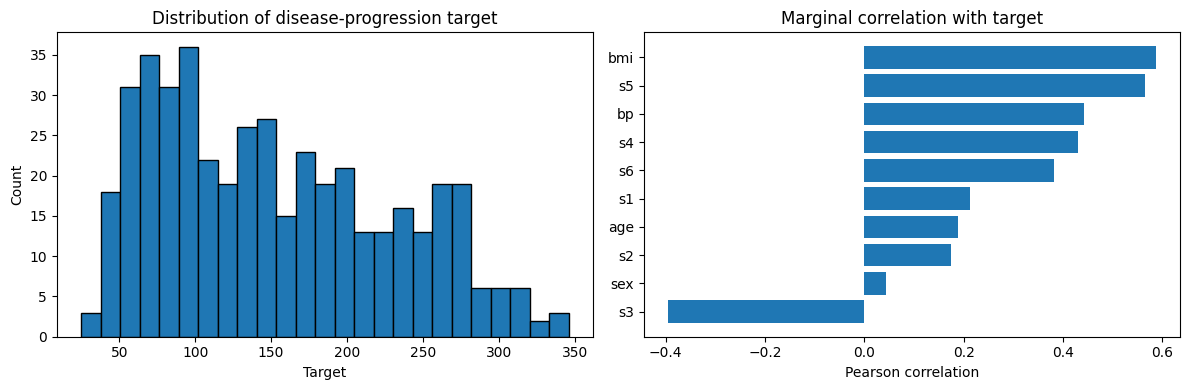

,corr_with_target
s3,-0.3948
sex,0.0431
s2,0.1741
age,0.1879
s1,0.2120
s6,0.3825
s4,0.4305
bp,0.4415
s5,0.5659
bmi,0.5865


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["target"], bins=25, edgecolor="black")
axes[0].set_title("Distribution of disease-progression target")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("Count")

corr_to_target = (
    df.corr(numeric_only=True)["target"]
      .drop("target")
      .sort_values()
)

axes[1].barh(corr_to_target.index, corr_to_target.values)
axes[1].set_title("Marginal correlation with target")
axes[1].set_xlabel("Pearson correlation")

plt.tight_layout()
plt.show()

display(corr_to_target.to_frame("corr_with_target"))

### Interpretation

A correlation matrix is useful for exploration, but it does **not** solve the regression problem.

For example, suppose both BMI and a serum measurement are correlated with the response and also correlated with each other.

The regression model

$$
Y = \beta_0 + \beta_1 BMI + \beta_2 S_5 + \varepsilon
$$

attempts to estimate the separate contribution of each variable while controlling for the other.

That is one reason multiple regression is substantially more informative than a list of pairwise correlations.

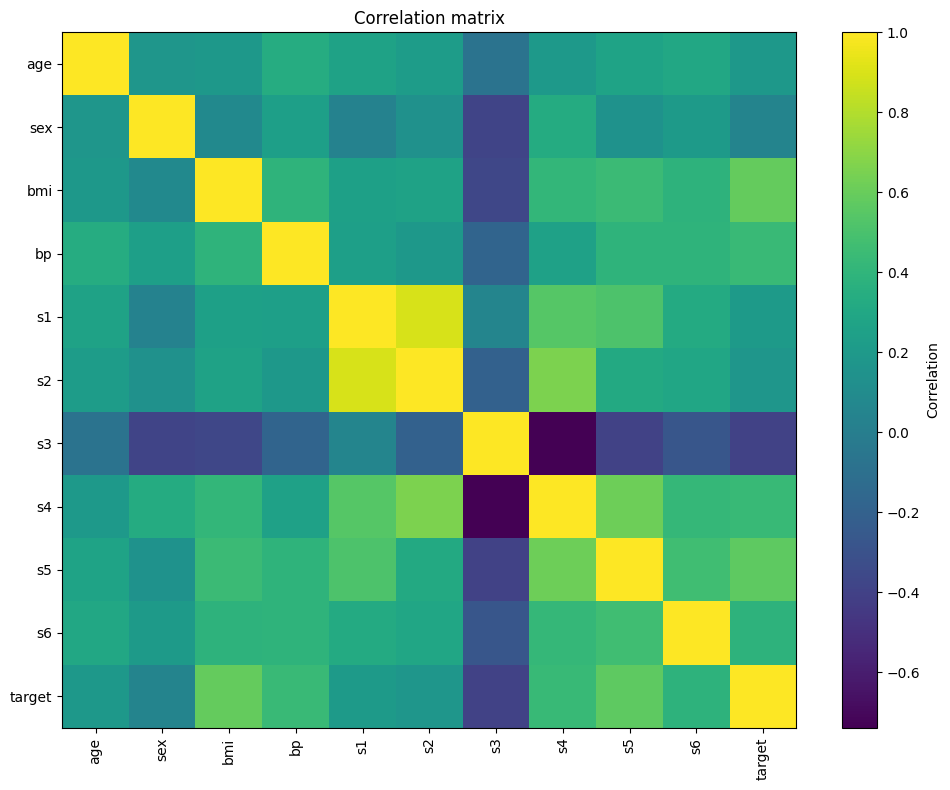

In [5]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title("Correlation matrix")

fig.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

## 4. Train/test split: inference versus prediction

Applied regression has two partially different goals.

### Inferential goal

Estimate and interpret quantities such as

$$
\beta_j,\qquad SE(\hat\beta_j),\qquad CI,\qquad p\text{-value}.
$$

### Predictive goal

Estimate performance on unseen observations.

We therefore keep a holdout set for predictive comparison while using the training data for model development.

This is not the only valid workflow, but it makes the difference between **in-sample statistical fit** and **out-of-sample generalization** explicit.

In [6]:
train_df, test_df = train_test_split(
    df,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (331, 11)
Test shape : (111, 11)


# Part I — Classical multiple linear regression

## 5. Fit the baseline OLS model

The multiple linear model is

$$
\mathbf y = \mathbf X\boldsymbol\beta + \boldsymbol\varepsilon.
$$

Ordinary least squares chooses

$$
\hat{\boldsymbol\beta}
=
\arg\min_{\boldsymbol\beta}
\|\mathbf y-\mathbf X\boldsymbol\beta\|_2^2.
$$

When $\mathbf X^\top\mathbf X$ is invertible,

$$
\hat{\boldsymbol\beta}
=
(\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top\mathbf y.
$$

We begin with all ten predictors so that diagnostics can tell us what is problematic.

In [7]:
BASE_FORMULA = (
    "target ~ age + sex + bmi + bp + s1 + s2 + s3 + s4 + s5 + s6"
)

ols_full = smf.ols(BASE_FORMULA, data=train_df).fit()
print(ols_full.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.519
Model:                            OLS   Adj. R-squared:                  0.504
Method:                 Least Squares   F-statistic:                     34.53
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           2.97e-45
Time:                        14:39:59   Log-Likelihood:                -1789.5
No. Observations:                 331   AIC:                             3601.
Df Residuals:                     320   BIC:                             3643.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    151.6652      3.023     50.162      0.0

## 6. Read the regression output systematically

Do not read a regression summary by scanning only for small p-values.

A disciplined sequence is:

1. **Overall model:** Is the regression collectively informative?
2. **Adjusted $R^2$:** How much variation is explained after accounting for model size?
3. **Individual coefficients:** Which effects are estimated precisely?
4. **Signs and magnitudes:** Are they scientifically sensible?
5. **Confidence intervals:** How uncertain are the estimates?
6. **Diagnostics:** Are the assumptions credible enough for the reported inference?

The reported coefficient $\hat\beta_j$ means:

> expected change in the response for a one-unit increase in predictor $X_j$, holding the other included predictors fixed.

Because the diabetes predictors are standardized, a one-unit change is **not** one raw clinical unit.

In [8]:
coef_table = pd.DataFrame({
    "coef": ols_full.params,
    "std_error": ols_full.bse,
    "t_stat": ols_full.tvalues,
    "p_value": ols_full.pvalues,
})

ci = ols_full.conf_int()
coef_table["ci_low"] = ci[0]
coef_table["ci_high"] = ci[1]

display(coef_table.sort_values("p_value"))

,coef,std_error,t_stat,p_value,ci_low,ci_high
Intercept,151.6652,3.0235,50.1624,0.0000,145.7168,157.6136
bmi,531.9711,79.0489,6.7296,0.0000,376.4499,687.4922
bp,381.5629,75.0577,5.0836,0.0000,233.8939,529.2318
s5,695.8081,196.6967,3.5375,0.0005,308.8261,"1,082.7901"
sex,-241.9909,70.7622,-3.4198,0.0007,-381.2088,-102.7730
s1,-918.5029,462.1211,-1.9876,0.0477,"-1,827.6822",-9.3236
s4,269.4923,190.6284,1.4137,0.1584,-105.5510,644.5357
s2,508.2578,372.8523,1.3632,0.1738,-225.2937,"1,241.8093"
age,47.7497,71.6419,0.6665,0.5056,-93.1989,188.6983
s3,116.9502,238.5081,0.4903,0.6242,-352.2919,586.1922


## 7. Overall $F$ test

The overall null hypothesis is

$$
H_0:\beta_1=\beta_2=\cdots=\beta_p=0.
$$

The alternative is that at least one slope is non-zero.

A significant overall $F$ test says the predictor set has explanatory information.

It does **not** imply:

- every variable is useful;
- the model assumptions are valid;
- the model is causal;
- the model predicts well out of sample.

In [9]:
print(f"Overall F statistic: {ols_full.fvalue:.4f}")
print(f"Overall F-test p-value: {ols_full.f_pvalue:.6g}")

Overall F statistic: 34.5328
Overall F-test p-value: 2.96669e-45


## 8. Partial $F$ test: test several coefficients together

A useful regression question is often not

$$
H_0:\beta_j=0
$$

for one variable, but instead whether a **group of variables** contributes after controlling for the rest.

We will test whether the anonymized serum variables `s1` through `s6` are jointly unnecessary:

$$
H_0:
\beta_{s1}=
\beta_{s2}=
\cdots=
\beta_{s6}=0.
$$

This compares nested models.

In [10]:
reduced_formula = "target ~ age + sex + bmi + bp"
ols_reduced = smf.ols(reduced_formula, data=train_df).fit()

partial_f = anova_lm(ols_reduced, ols_full)
display(partial_f)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,326.0000,"1,180,109.9505",0.0000,NaN,NaN,NaN
1,320.0000,"962,302.3199",6.0000,"217,807.6306",12.0715,0.0000


### How to interpret the partial $F$ test

- A small p-value means the larger model improves fit enough that the tested group should not be discarded collectively.
- A large p-value means the extra variables have not demonstrated sufficient incremental explanatory value.

Notice the conceptual difference between:

- **individual t-tests**, and
- a **joint F-test**.

Several coefficients can be individually imprecise while the group is jointly important, especially when predictors are correlated.

# Part II — Diagnostics

## 9. Why diagnostics matter

OLS inference relies on assumptions about the regression structure and errors.

A useful checklist is:

$$
E[\varepsilon\mid X]=0
$$

and, for the simplest classical model,

$$
Var(\varepsilon\mid X)=\sigma^2.
$$

For textbook small-sample inference, normality of the errors is also useful.

Diagnostics ask whether the model has left systematic information in the residuals.

If it has, the model is not yet finished.

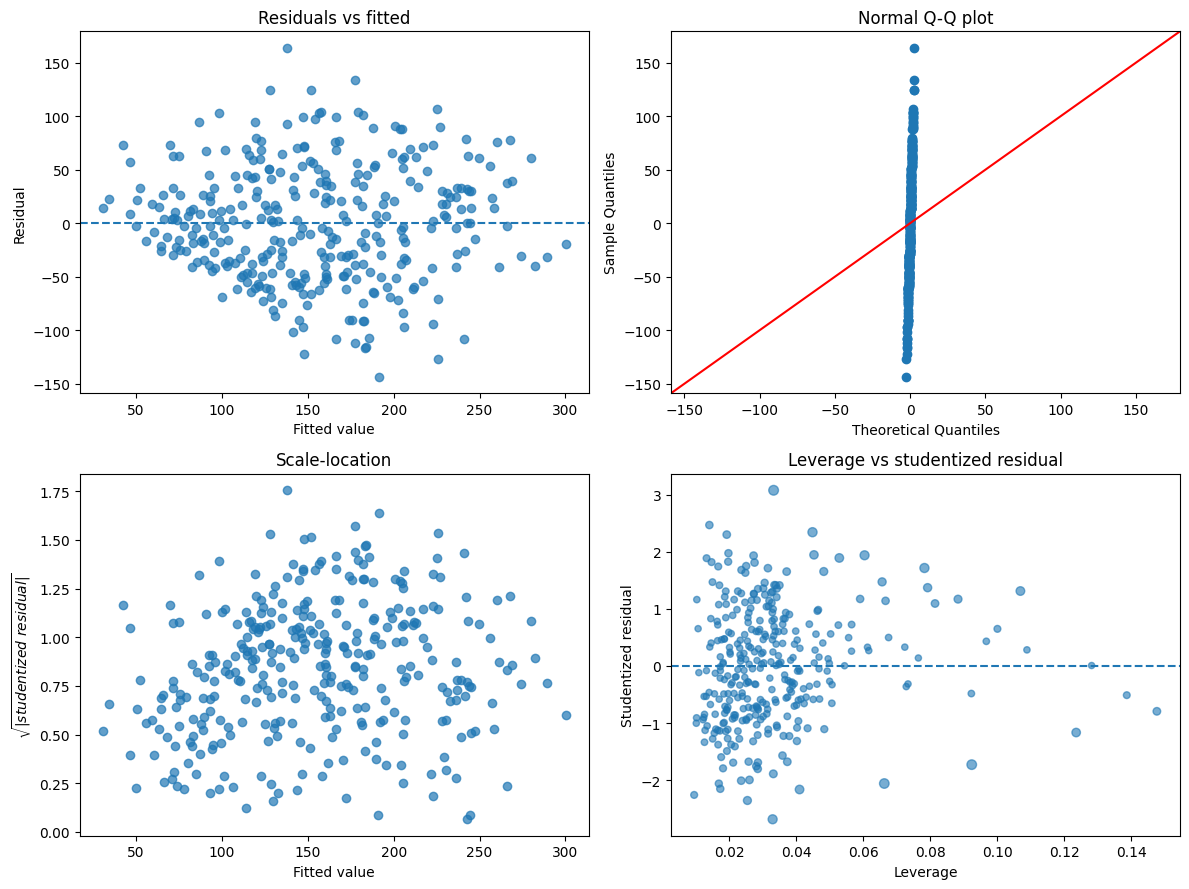

,diagnostic,statistic,p_value,interpretation_hint
0,Breusch-Pagan LM,18.1555,0.0524,small p => non-constant variance evidence
1,Breusch-Pagan F,1.8571,0.0505,small p => non-constant variance evidence
2,Jarque-Bera,1.9337,0.3803,small p => residual normality questioned
3,Durbin-Watson,1.7736,NaN,near 2 => little first-order residual autocorr...


In [11]:
@dataclass
class RegressionDiagnostics:
    result: object

    def residual_frame(self) -> pd.DataFrame:
        infl = self.result.get_influence()
        return pd.DataFrame({
            "fitted": self.result.fittedvalues,
            "resid": self.result.resid,
            "studentized_resid": infl.resid_studentized_external,
            "leverage": infl.hat_matrix_diag,
            "cooks_d": infl.cooks_distance[0],
        })

    def assumption_tests(self) -> pd.DataFrame:
        resid = self.result.resid
        exog = self.result.model.exog

        bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(resid, exog)
        jb_stat, jb_p, skew, kurt = jarque_bera(resid)
        dw = durbin_watson(resid)

        return pd.DataFrame({
            "diagnostic": [
                "Breusch-Pagan LM",
                "Breusch-Pagan F",
                "Jarque-Bera",
                "Durbin-Watson",
            ],
            "statistic": [bp_lm, bp_f, jb_stat, dw],
            "p_value": [bp_lm_p, bp_f_p, jb_p, np.nan],
            "interpretation_hint": [
                "small p => non-constant variance evidence",
                "small p => non-constant variance evidence",
                "small p => residual normality questioned",
                "near 2 => little first-order residual autocorrelation",
            ],
        })

    def plot_core(self):
        diag = self.residual_frame()

        fig, axes = plt.subplots(2, 2, figsize=(12, 9))

        axes[0, 0].scatter(diag["fitted"], diag["resid"], alpha=0.7)
        axes[0, 0].axhline(0, linestyle="--")
        axes[0, 0].set_title("Residuals vs fitted")
        axes[0, 0].set_xlabel("Fitted value")
        axes[0, 0].set_ylabel("Residual")

        sm.qqplot(self.result.resid, line="45", ax=axes[0, 1])
        axes[0, 1].set_title("Normal Q-Q plot")

        axes[1, 0].scatter(
            diag["fitted"],
            np.sqrt(np.abs(diag["studentized_resid"])),
            alpha=0.7,
        )
        axes[1, 0].set_title("Scale-location")
        axes[1, 0].set_xlabel("Fitted value")
        axes[1, 0].set_ylabel(r"$\sqrt{|studentized\ residual|}$")

        axes[1, 1].scatter(
            diag["leverage"],
            diag["studentized_resid"],
            s=20 + 1000 * diag["cooks_d"],
            alpha=0.6,
        )
        axes[1, 1].axhline(0, linestyle="--")
        axes[1, 1].set_title("Leverage vs studentized residual")
        axes[1, 1].set_xlabel("Leverage")
        axes[1, 1].set_ylabel("Studentized residual")

        plt.tight_layout()
        plt.show()


diag = RegressionDiagnostics(ols_full)
diag.plot_core()
display(diag.assumption_tests())

## 10. Reading the four diagnostic views

### Residuals versus fitted

Ideally, residuals should form an unstructured horizontal cloud around zero.

Patterns may suggest:

- curvature $\rightarrow$ missing nonlinear structure;
- funnel shape $\rightarrow$ heteroskedasticity;
- clusters $\rightarrow$ omitted groups or regimes.

### Q-Q plot

If residuals are approximately normal, points should lie roughly on the reference line.

Tail departures can signal:

- heavy tails;
- outliers;
- skewness.

### Scale-location plot

This focuses on whether residual spread changes with the fitted value.

### Leverage versus studentized residual

Observations become especially important when they combine:

- unusual predictor values;
- a large regression residual.

This motivates influence analysis.

## 11. Outliers, leverage and influence

These terms are not synonyms.

### Outlier

An observation with an unusual response relative to the fitted model.

### Leverage

An observation with unusual predictor coordinates.

If

$$
\hat{\mathbf y}=H\mathbf y,
$$

then

$$
H=X(X^\top X)^{-1}X^\top
$$

is the hat matrix and $h_{ii}$ is the leverage of observation $i$.

### Influence

How much the fitted regression changes because the observation is present.

Cook's distance combines residual size with leverage.

A high-leverage observation is not automatically bad. A high-leverage observation with a large residual deserves much closer inspection.

In [12]:
influence_df = diag.residual_frame().copy()
influence_df["row_index"] = influence_df.index

n = len(train_df)
p = int(ols_full.df_model) + 1

influence_df["high_leverage"] = influence_df["leverage"] > (2 * p / n)
influence_df["high_cooks"] = influence_df["cooks_d"] > (4 / n)
influence_df["large_studentized_resid"] = (
    influence_df["studentized_resid"].abs() > 2
)

display(
    influence_df.sort_values("cooks_d", ascending=False).head(15)
)

,fitted,resid,studentized_resid,leverage,cooks_d,row_index,high_leverage,high_cooks,large_studentized_resid
102,138.0395,163.9605,3.0811,0.0333,0.0290,102,False,True,True
123,174.1150,-90.1150,-1.7303,0.0924,0.0275,123,True,True,False
382,240.6648,-108.6648,-2.0611,0.0663,0.0272,382,False,True,True
304,128.1616,124.8384,2.3457,0.0449,0.0232,304,False,True,True
141,226.8193,90.1807,1.7182,0.0783,0.0227,141,True,True,False
92,191.5753,-143.5753,-2.6883,0.0330,0.0220,92,False,True,True
387,98.2540,102.7460,1.9413,0.0604,0.0219,387,False,True,False
58,101.9627,68.0373,1.3144,0.1070,0.0188,58,True,True,False
29,182.3044,100.6956,1.8945,0.0529,0.0181,29,False,True,False
289,183.6605,-115.6605,-2.1662,0.0410,0.0180,289,False,True,True


### Practical interpretation

Rules such as

$$
h_{ii} > \frac{2p}{n}
$$

or

$$
D_i > \frac{4}{n}
$$

are screening heuristics, not laws.

An influential point should trigger investigation:

- Was there a data-entry problem?
- Is the observation from a genuinely different subpopulation?
- Does the current functional form fail locally?
- Does the scientific conclusion materially change if it is excluded?

Never delete an observation merely because a diagnostic value is large.

## 12. Multicollinearity and VIF

If one predictor can be closely reconstructed from the others, its regression coefficient becomes difficult to estimate precisely.

For predictor $X_j$,

$$
VIF_j
=
\frac{1}{1-R_j^2},
$$

where $R_j^2$ comes from regressing $X_j$ on the remaining predictors.

As

$$
R_j^2\rightarrow1,
$$

the VIF grows.

Consequences of multicollinearity include:

- unstable coefficients;
- inflated standard errors;
- coefficient signs that change across specifications;
- strong overall fit but weak-looking individual t-tests.

Multicollinearity primarily threatens **interpretation and coefficient stability**, not necessarily prediction.

In [13]:
def compute_vif(data: pd.DataFrame, predictors: Sequence[str]) -> pd.DataFrame:
    X = sm.add_constant(data[list(predictors)], has_constant="add")
    rows = []

    for i, col in enumerate(X.columns):
        if col == "const":
            continue

        rows.append({
            "variable": col,
            "VIF": variance_inflation_factor(X.values, i),
        })

    return (
        pd.DataFrame(rows)
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )

predictors = ["age", "sex", "bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6"]
vif_table = compute_vif(train_df, predictors)
display(vif_table)

,variable,VIF
0,s1,54.2966
1,s2,35.5955
2,s3,13.8362
3,s5,9.8005
4,s4,9.3172
5,bmi,1.5284
6,s6,1.4612
7,bp,1.4185
8,sex,1.2478
9,age,1.2157


# Part III — Remedial measures

## 13. Robust standard errors: same coefficients, different uncertainty estimate

Heteroskedasticity does not automatically make the OLS coefficient estimator useless.

However, the classical standard-error formula can become unreliable.

A common remedy is a heteroskedasticity-consistent covariance estimator such as **HC3**.

The fitted coefficients stay the same, but

$$
SE(\hat\beta_j)
$$

and therefore t-statistics, confidence intervals and p-values can change.

This is an important distinction:

> **robust standard errors repair inference, not the functional form of the regression.**

In [14]:
ols_hc3 = ols_full.get_robustcov_results(cov_type="HC3")

classic_vs_robust = pd.DataFrame({
    "coefficient": ols_full.model.exog_names,
    "estimate": ols_full.params.values,
    "classical_SE": ols_full.bse.values,
    "HC3_SE": np.asarray(ols_hc3.bse),
    "classical_p": ols_full.pvalues.values,
    "HC3_p": np.asarray(ols_hc3.pvalues),
})

display(classic_vs_robust)

,coefficient,estimate,classical_SE,HC3_SE,classical_p,HC3_p
0,Intercept,151.6652,3.0235,3.0460,0.0000,0.0000
1,age,47.7497,71.6419,71.6867,0.5056,0.5058
2,sex,-241.9909,70.7622,67.9813,0.0007,0.0004
3,bmi,531.9711,79.0489,83.6095,0.0000,0.0000
4,bp,381.5629,75.0577,77.1909,0.0000,0.0000
5,s1,-918.5029,462.1211,438.3615,0.0477,0.0369
6,s2,508.2578,372.8523,343.9891,0.1738,0.1405
7,s3,116.9502,238.5081,230.7450,0.6242,0.6126
8,s4,269.4923,190.6284,195.9928,0.1584,0.1701
9,s5,695.8081,196.6967,186.8187,0.0005,0.0002


## 14. Weighted least squares

If the conditional error variance changes across observations,

$$
Var(\varepsilon_i\mid X_i)=\sigma_i^2,
$$

ordinary least squares gives every observation equal weight.

Weighted least squares instead minimizes

$$
\sum_i w_i(y_i-x_i^\top\beta)^2,
$$

often with

$$
w_i\propto\frac{1}{\sigma_i^2}.
$$

Here we construct a simple pedagogical variance model from the squared OLS residuals.

This is **not** claimed to be the uniquely correct variance model. It demonstrates the mechanics and statistical idea.

In [15]:
# Step 1: model log(residual^2) as a function of fitted values.
eps = 1e-8

variance_df = pd.DataFrame({
    "resid_sq": ols_full.resid**2,
    "fitted": ols_full.fittedvalues,
})
variance_df["log_resid_sq"] = np.log(variance_df["resid_sq"] + eps)

variance_model = smf.ols(
    "log_resid_sq ~ fitted",
    data=variance_df,
).fit()

pred_log_var = variance_model.predict(variance_df)
pred_var = np.exp(pred_log_var)

# Step 2: inverse-variance weights.
weights = 1 / np.clip(pred_var, 1e-6, None)

wls_full = smf.wls(
    BASE_FORMULA,
    data=train_df,
    weights=weights,
).fit()

comparison_wls = pd.DataFrame({
    "OLS": ols_full.params,
    "WLS": wls_full.params,
})
display(comparison_wls)

print("\nWLS summary:")
print(wls_full.summary())

,OLS,WLS
Intercept,151.6652,151.5787
age,47.7497,35.8113
sex,-241.9909,-254.7763
bmi,531.9711,497.2775
bp,381.5629,375.9228
s1,-918.5029,-715.4140
s2,508.2578,358.5441
s3,116.9502,26.8687
s4,269.4923,238.0019
s5,695.8081,634.0360



WLS summary:
                            WLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.502
Model:                            WLS   Adj. R-squared:                  0.487
Method:                 Least Squares   F-statistic:                     32.29
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           6.23e-43
Time:                        14:40:01   Log-Likelihood:                -1785.4
No. Observations:                 331   AIC:                             3593.
Df Residuals:                     320   BIC:                             3635.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    151.5787      2.993     5

## 15. Response transformation with Box-Cox

A transformation can sometimes:

- stabilize variance;
- make the response distribution more regular;
- linearize a relationship.

The Box-Cox family is

$$
Y^{(\lambda)}
=
\begin{cases}
\dfrac{Y^\lambda-1}{\lambda}, & \lambda\neq0,\\[6pt]
\log Y, & \lambda=0.
\end{cases}
$$

The diabetes target is positive, so Box-Cox is defined directly.

A transformation should be motivated by model behaviour and interpretability—not applied automatically.

Estimated Box-Cox lambda: 0.3683


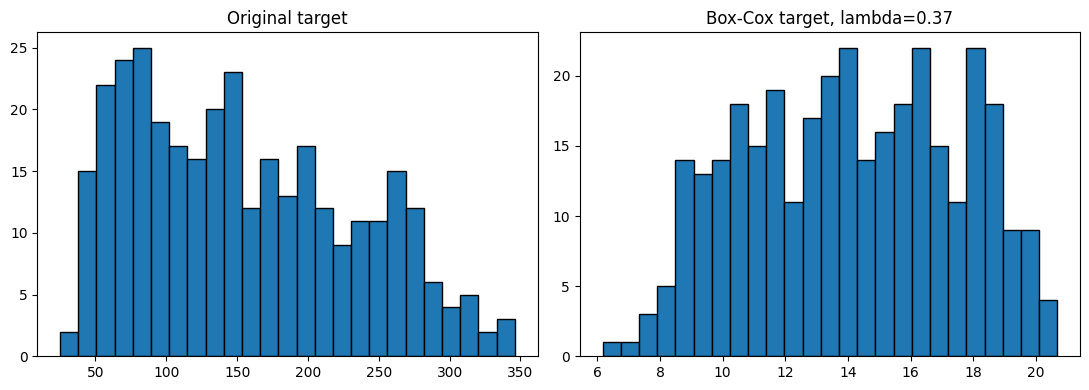

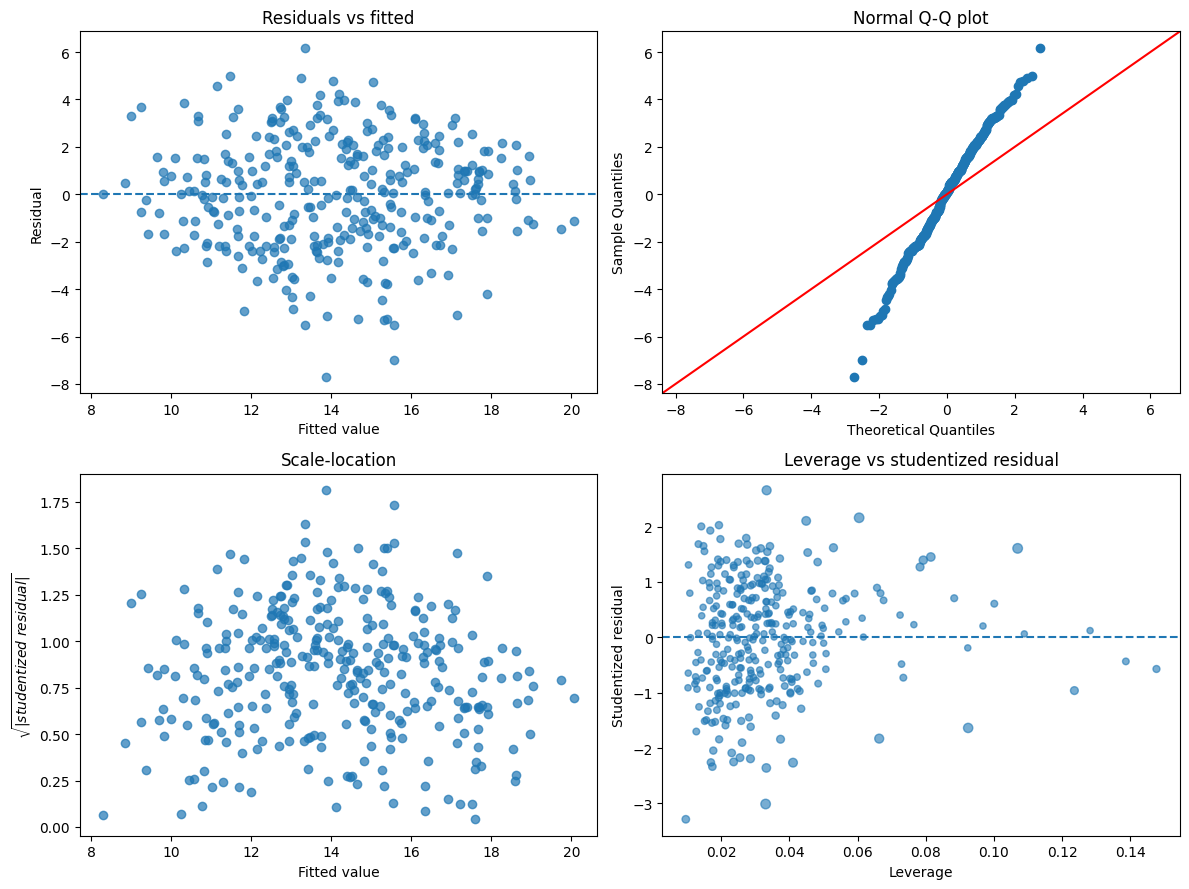

In [16]:
y_train = train_df["target"].to_numpy()
y_boxcox, lambda_hat = stats.boxcox(y_train)

print(f"Estimated Box-Cox lambda: {lambda_hat:.4f}")

train_boxcox = train_df.copy()
train_boxcox["target_boxcox"] = y_boxcox

boxcox_formula = (
    "target_boxcox ~ age + sex + bmi + bp + s1 + s2 + s3 + s4 + s5 + s6"
)
ols_boxcox = smf.ols(boxcox_formula, data=train_boxcox).fit()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(train_df["target"], bins=25, edgecolor="black")
axes[0].set_title("Original target")
axes[1].hist(train_boxcox["target_boxcox"], bins=25, edgecolor="black")
axes[1].set_title(f"Box-Cox target, lambda={lambda_hat:.2f}")
plt.tight_layout()
plt.show()

RegressionDiagnostics(ols_boxcox).plot_core()

### Interpretation caveat

A transformed response changes the meaning of coefficients.

For example, if one models

$$
\log(Y)=X\beta+\varepsilon,
$$

then a coefficient is naturally interpreted on the log scale and often converted into an approximate multiplicative or percentage effect.

Model diagnostics may improve while interpretability becomes less direct.

That trade-off is part of applied modelling.

# Part IV — Nonlinearity and interactions

## 16. Polynomial terms

A relationship can be nonlinear in a predictor while the model remains linear in its coefficients.

For example,

$$
Y
=
\beta_0+\beta_1 BMI+\beta_2 BMI^2+\varepsilon.
$$

This is polynomial regression.

It is still a linear model because the unknown parameters $\beta_0,\beta_1,\beta_2$ enter linearly.

We test whether adding a quadratic BMI term improves the baseline model.

In [17]:
poly_formula = (
    "target ~ age + sex + bmi + I(bmi**2) + bp + "
    "s1 + s2 + s3 + s4 + s5 + s6"
)

ols_poly = smf.ols(poly_formula, data=train_df).fit()

display(anova_lm(ols_full, ols_poly))

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,320.0000,"962,302.3199",0.0000,NaN,NaN,NaN
1,319.0000,"948,276.2084",1.0000,"14,026.1115",4.7184,0.0306


## 17. Interaction effects

Suppose the effect of BMI depends on blood pressure.

An additive model assumes

$$
E[Y\mid BMI,BP]
=
\beta_0+\beta_1 BMI+\beta_2 BP.
$$

An interaction model uses

$$
E[Y\mid BMI,BP]
=
\beta_0+\beta_1 BMI+\beta_2 BP+\beta_3(BMI\times BP).
$$

Then

$$
\frac{\partial E[Y]}{\partial BMI}
=
\beta_1+\beta_3 BP.
$$

So BMI no longer has one universal slope.

The interaction coefficient asks whether the BMI association changes according to blood-pressure level.

In [18]:
interaction_formula = (
    "target ~ age + sex + bmi * bp + s1 + s2 + s3 + s4 + s5 + s6"
)

ols_interaction = smf.ols(interaction_formula, data=train_df).fit()

display(anova_lm(ols_full, ols_interaction))

print("\nInteraction coefficient:")
display(
    pd.DataFrame({
        "coef": ols_interaction.params,
        "p_value": ols_interaction.pvalues,
    }).loc[["bmi:bp"]]
)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,320.0000,"962,302.3199",0.0000,NaN,NaN,NaN
1,319.0000,"947,310.9829",1.0000,"14,991.3370",5.0482,0.0253



Interaction coefficient:


,coef,p_value
bmi:bp,"2,865.9793",0.0253


# Part V — Model selection

## 18. Why variable selection is not simply 'keep every p < 0.05 variable'

A model with too many variables can become:

- unstable;
- difficult to interpret;
- unnecessarily high-variance.

A model with too few variables can omit important structure and become biased.

One classical model-selection criterion is

$$
AIC=-2\log L+2k.
$$

Lower AIC is preferred among models fitted to the same response data.

AIC balances fit against complexity.

The following reusable backward-elimination class repeatedly removes the variable whose removal most improves AIC.

This is a pedagogical implementation of classical stepwise thinking—not a claim that stepwise AIC is always the best modern strategy.

In [19]:
@dataclass
class BackwardAICSelector:
    response: str
    predictors: Sequence[str]

    def fit(self, data: pd.DataFrame):
        current = list(self.predictors)
        history = []

        while True:
            current_formula = f"{self.response} ~ " + " + ".join(current)
            current_model = smf.ols(current_formula, data=data).fit()
            current_aic = current_model.aic

            candidates = []

            for var in current:
                candidate_vars = [v for v in current if v != var]

                if not candidate_vars:
                    continue

                candidate_formula = (
                    f"{self.response} ~ " + " + ".join(candidate_vars)
                )
                model = smf.ols(candidate_formula, data=data).fit()

                candidates.append({
                    "removed": var,
                    "aic": model.aic,
                    "model": model,
                    "variables": candidate_vars,
                })

            if not candidates:
                break

            best = min(candidates, key=lambda x: x["aic"])

            if best["aic"] < current_aic - 1e-9:
                history.append({
                    "step": len(history) + 1,
                    "removed": best["removed"],
                    "old_aic": current_aic,
                    "new_aic": best["aic"],
                })
                current = best["variables"]
            else:
                break

        final_formula = f"{self.response} ~ " + " + ".join(current)
        final_model = smf.ols(final_formula, data=data).fit()

        return final_model, pd.DataFrame(history)


selector = BackwardAICSelector(
    response="target",
    predictors=predictors,
)

ols_selected, selection_history = selector.fit(train_df)

display(selection_history)
print("\nSelected formula:")
print(ols_selected.model.formula)
print("\nSelected-model AIC:", ols_selected.aic)

,step,removed,old_aic,new_aic
0,1,s6,"3,601.0509","3,599.1722"
1,2,s3,"3,599.1722","3,597.4306"
2,3,age,"3,597.4306","3,595.9841"



Selected formula:
target ~ sex + bmi + bp + s1 + s2 + s4 + s5

Selected-model AIC: 3595.98409833154


## 19. Compare models in-sample and out-of-sample

A statistically appealing in-sample model does not automatically generalize better.

We compare:

- full OLS;
- reduced OLS;
- AIC-selected OLS;
- polynomial model;
- interaction model.

For prediction, we report:

$$
RMSE
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat y_i)^2
}
$$

and

$$
MAE
=
\frac{1}{n}
\sum_{i=1}^{n}|y_i-\hat y_i|.
$$

In [20]:
@dataclass
class ModelComparator:
    models: dict

    def evaluate(self, test_data: pd.DataFrame) -> pd.DataFrame:
        rows = []

        for name, model in self.models.items():
            pred = model.predict(test_data)
            y_true = test_data["target"]

            rows.append({
                "model": name,
                "AIC_train": model.aic,
                "BIC_train": model.bic,
                "adj_R2_train": model.rsquared_adj,
                "RMSE_test": np.sqrt(mean_squared_error(y_true, pred)),
                "MAE_test": mean_absolute_error(y_true, pred),
            })

        return (
            pd.DataFrame(rows)
            .sort_values(["RMSE_test", "AIC_train"])
            .reset_index(drop=True)
        )


models = {
    "Full OLS": ols_full,
    "Reduced OLS": ols_reduced,
    "AIC-selected OLS": ols_selected,
    "Polynomial OLS": ols_poly,
    "Interaction OLS": ols_interaction,
}

comparison = ModelComparator(models).evaluate(test_df)
display(comparison)

,model,AIC_train,BIC_train,adj_R2_train,RMSE_test,MAE_test
0,Interaction OLS,"3,597.8538","3,643.4792",0.5102,52.2004,40.6598
1,AIC-selected OLS,"3,595.9841","3,626.4010",0.5072,53.1587,41.4080
2,Full OLS,"3,601.0509","3,642.8742",0.5040,53.3696,41.5485
3,Polynomial OLS,"3,598.1909","3,643.8163",0.5097,53.5218,41.8998
4,Reduced OLS,"3,656.5862","3,675.5968",0.4029,59.5216,47.9278


### Important lesson

Different criteria answer different questions.

- **AIC/BIC** assess penalized in-sample likelihood.
- **Adjusted $R^2$** measures explained variation with a complexity adjustment.
- **RMSE/MAE on the test set** estimate predictive generalization.

A model can rank well on one criterion and less well on another.

There is no contradiction: the criteria are evaluating different modelling objectives.

# Part VI — Non-least-squares estimation

## 20. Median regression using quantile regression

OLS minimizes squared error:

$$
\sum_i e_i^2.
$$

Median regression solves a different optimization problem based on absolute asymmetric loss.

For the median, $\tau=0.5$.

Conceptually, instead of modelling

$$
E[Y\mid X],
$$

we model the conditional median

$$
Q_{0.5}(Y\mid X).
$$

Because large residuals are not squared, median regression can be less dominated by extreme outcomes.

In [21]:
quantile_formula = "target ~ age + sex + bmi + bp + s5"

median_reg = smf.quantreg(
    quantile_formula,
    data=train_df,
).fit(q=0.5)

ols_same_vars = smf.ols(
    quantile_formula,
    data=train_df,
).fit()

median_vs_mean = pd.DataFrame({
    "OLS_mean_regression": ols_same_vars.params,
    "Quantile_median_regression": median_reg.params,
})

display(median_vs_mean)

print("\nMedian regression summary:")
print(median_reg.summary())

,OLS_mean_regression,Quantile_median_regression
Intercept,151.6460,146.9600
age,-8.1930,-58.4448
sex,-115.7794,-254.1132
bmi,637.1591,656.0867
bp,330.6491,350.6762
s5,477.4756,514.2864



Median regression summary:
                         QuantReg Regression Results                          
Dep. Variable:                 target   Pseudo R-squared:               0.2928
Model:                       QuantReg   Bandwidth:                       44.51
Method:                 Least Squares   Sparsity:                        161.0
Date:                Wed, 09 Sep 2026   No. Observations:                  331
Time:                        14:40:03   Df Residuals:                      325
                                        Df Model:                            5
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    146.9600      4.430     33.175      0.000     138.245     155.675
age          -58.4448    102.803     -0.569      0.570    -260.688     143.798
sex         -254.1132     95.203     -2.669      0.008    -441.405     -66.822
bmi          656.0867   

### What changed conceptually?

OLS asks:

> How do predictors shift the **conditional mean**?

Median regression asks:

> How do predictors shift the **conditional median**?

That distinction can matter when the response distribution is:

- skewed;
- heavy-tailed;
- affected by extreme observations.

This is a clean example of why "regression" is broader than ordinary least squares.

# Part VII — ANOVA and ANCOVA as regression

## 21. Create categorical factors from the same case-study dataset

The original dataset is mainly continuous.

To demonstrate ANOVA/ANCOVA using the same case study, we construct pedagogical groups:

- `bmi_group`: quartiles of standardized BMI;
- `sex_group`: the two anonymized values of the dataset's binary-coded `sex` feature.

We deliberately call the latter **group A / group B** rather than assigning biological labels because the sklearn dataset documentation does not expose such semantic labels here.

This lets us show that ANOVA is not a separate universe—it is regression with categorical predictors.

In [22]:
anova_df = train_df.copy()

anova_df["bmi_group"] = pd.qcut(
    anova_df["bmi"],
    q=4,
    labels=["Q1_low", "Q2", "Q3", "Q4_high"],
)

anova_df["sex_group"] = np.where(
    anova_df["sex"] > anova_df["sex"].median(),
    "Group_B",
    "Group_A",
)

display(
    anova_df.groupby("bmi_group", observed=False)["target"]
            .agg(["count", "mean", "std"])
)

,count,mean,std
bmi_group,,,
Q1_low,87,103.8736,49.4116
Q2,80,130.8250,65.8494
Q3,83,174.6145,71.3992
Q4_high,81,211.0123,76.6599


## 22. One-way ANOVA

The one-factor ANOVA model can be written

$$
Y_{ij}
=
\mu+\tau_i+\varepsilon_{ij}.
$$

Using regression notation, this is simply

$$
Y
=
\beta_0+
\beta_1D_1+
\beta_2D_2+
\beta_3D_3+
\varepsilon,
$$

where the $D_j$ are dummy variables.

We ask whether mean disease progression differs across BMI quartile groups.

In [23]:
oneway = smf.ols(
    "target ~ C(bmi_group)",
    data=anova_df,
).fit()

display(anova_lm(oneway, typ=2))
print(oneway.summary())

,sum_sq,df,F,PR(>F)
C(bmi_group),"560,082.9277",3.0000,42.3749,0.0000
Residual,"1,440,687.8095",327.0000,NaN,NaN


                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.273
Method:                 Least Squares   F-statistic:                     42.37
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           3.69e-23
Time:                        14:40:03   Log-Likelihood:                -1856.3
No. Observations:                 331   AIC:                             3721.
Df Residuals:                     327   BIC:                             3736.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

## 23. Two-way ANOVA and interaction

With two categorical factors,

$$
Y_{ijk}
=
\mu+
\alpha_i+
\beta_j+
(\alpha\beta)_{ij}
+
\varepsilon_{ijk}.
$$

The interaction asks:

> Does the effect of one factor depend on the level of the other factor?

That is exactly the same interaction idea seen earlier for continuous predictors.

In [24]:
twoway = smf.ols(
    "target ~ C(bmi_group) * C(sex_group)",
    data=anova_df,
).fit()

display(anova_lm(twoway, typ=2))

,sum_sq,df,F,PR(>F)
C(bmi_group),"559,693.2995",3.0000,42.4973,0.0000
C(sex_group),0.0354,1.0000,0.0000,0.9977
C(bmi_group):C(sex_group),"22,708.5990",3.0000,1.7243,0.1618
Residual,"1,417,979.1750",323.0000,NaN,NaN


## 24. ANCOVA

ANCOVA combines:

- a categorical grouping variable;
- one or more continuous covariates.

Suppose we compare BMI groups while adjusting for blood pressure:

$$
Y
=
\beta_0+
\text{BMI-group effects}
+
\beta_{bp}BP
+
\varepsilon.
$$

The BMI-group comparison is therefore made **conditional on blood pressure**.

This illustrates the unifying principle:

$$
\boxed{
\text{Regression},\ \text{ANOVA},\ \text{ANCOVA}
\text{ are all linear models with different design matrices.}
}
$$

In [25]:
ancova = smf.ols(
    "target ~ C(bmi_group) + bp",
    data=anova_df,
).fit()

display(anova_lm(ancova, typ=2))
print(ancova.summary())

,sum_sq,df,F,PR(>F)
C(bmi_group),"323,320.9934",3.0000,27.2960,0.0000
bp,"153,533.4774",1.0000,38.8857,0.0000
Residual,"1,287,154.3321",326.0000,NaN,NaN


                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.357
Model:                            OLS   Adj. R-squared:                  0.349
Method:                 Least Squares   F-statistic:                     45.18
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           3.52e-30
Time:                        14:40:03   Log-Likelihood:                -1837.7
No. Observations:                 331   AIC:                             3685.
Df Residuals:                     326   BIC:                             3704.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

## 25. ANCOVA slope-homogeneity check

A classical ANCOVA model often assumes that the continuous covariate has the same slope in every group.

We can test that assumption by adding an interaction:

$$
C(\text{BMI group})\times BP.
$$

If the interaction is important, the "common slope" ANCOVA interpretation is too simple.

In [26]:
ancova_interaction = smf.ols(
    "target ~ C(bmi_group) * bp",
    data=anova_df,
).fit()

display(anova_lm(ancova, ancova_interaction))

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,326.0000,"1,287,154.3321",0.0000,NaN,NaN,NaN
1,323.0000,"1,254,528.7651",3.0000,"32,625.5670",2.8000,0.0401


# Part VIII — Bridge to generalized linear models

## 26. Why ordinary linear regression is a special GLM

A generalized linear model has three components:

1. **Random component:** distribution of the response;
2. **Systematic component:** linear predictor
   $$
   \eta=X\beta;
   $$
3. **Link function:**
   $$
   g(\mu)=\eta.
   $$

Ordinary Gaussian regression uses the identity link:

$$
g(\mu)=\mu.
$$

Therefore,

$$
\mu=X\beta.
$$

For a binary response, a binomial GLM commonly uses the logit link:

$$
\log\frac{p}{1-p}=X\beta.
$$

To demonstrate the mechanics, we create a binary pedagogical outcome indicating whether progression is above the training-set median.

In [27]:
glm_df = train_df.copy()
cutoff = glm_df["target"].median()

glm_df["high_progression"] = (
    glm_df["target"] > cutoff
).astype(int)

binomial_glm = smf.glm(
    "high_progression ~ age + sex + bmi + bp + s5",
    data=glm_df,
    family=sm.families.Binomial(),
).fit()

print(binomial_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       high_progression   No. Observations:                  331
Model:                            GLM   Df Residuals:                      325
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -170.36
Date:                Wed, 09 Sep 2026   Deviance:                       340.71
Time:                        14:40:03   Pearson chi2:                     312.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3001
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0691      0.133     -0.519      0.6

### Interpret the logistic-regression coefficient

For predictor $X_j$,

$$
\beta_j
$$

is the change in **log odds** associated with a one-unit increase in $X_j$, holding other predictors fixed.

Exponentiating gives an odds ratio:

$$
OR_j=e^{\beta_j}.
$$

An odds ratio above 1 means the odds increase; below 1 means they decrease.

Again, this binary target was created only to demonstrate the GLM connection. It is not a proposed clinical classification rule.

In [28]:
odds_ratios = pd.DataFrame({
    "coefficient": binomial_glm.params,
    "odds_ratio": np.exp(binomial_glm.params),
    "p_value": binomial_glm.pvalues,
})

display(odds_ratios)

,coefficient,odds_ratio,p_value
Intercept,-0.0691,0.9333,0.6041
age,-0.0572,0.9444,0.9854
sex,-7.6964,0.0005,0.0092
bmi,14.5683,"2,122,907.7461",0.0000
bp,11.1377,"68,710.6919",0.0007
s5,15.7566,"6,966,643.8427",0.0000


# Part IX — A reusable applied-regression workflow

## 27. What should you do when given a new regression dataset?

Use the following checklist.

### Step 1 — Define the scientific/statistical question

Is the goal:

- explanation?
- inference?
- prediction?
- adjustment?
- group comparison?

### Step 2 — Explore

Inspect:

- distributions;
- scatterplots;
- correlations;
- missingness;
- strange values;
- group structure.

### Step 3 — Specify the initial model

Use domain knowledge before relying on automated selection.

### Step 4 — Fit the model

Start with an interpretable baseline.

### Step 5 — Perform inference

Inspect:

- coefficient estimates;
- standard errors;
- confidence intervals;
- t-tests;
- overall and partial F-tests.

### Step 6 — Diagnose assumptions

Check:

- linearity;
- residual variance;
- residual distribution;
- leverage;
- influence;
- multicollinearity.

### Step 7 — Apply defensible remedies

Possibilities include:

- transformations;
- nonlinear terms;
- interactions;
- heteroskedasticity-robust standard errors;
- WLS;
- alternative estimators.

### Step 8 — Compare specifications

Use criteria appropriate to the goal:

- AIC/BIC;
- adjusted $R^2$;
- partial $F$ tests;
- holdout RMSE/MAE.

### Step 9 — Interpret in domain language

A statistically significant coefficient is not automatically:

- large;
- useful;
- causal;
- practically important.

### Step 10 — Document limitations

Every serious applied analysis should explicitly state what the model cannot establish.

# Part X — Exercises

## 28. Suggested exercises

### Exercise 1 — Reduced regression

Fit a model containing only:

- `bmi`
- `bp`
- `s5`

Compare it with the full OLS model using:

- adjusted $R^2$;
- AIC;
- BIC;
- test RMSE.

Explain why the model preferred by AIC need not be the one with the lowest holdout RMSE.

### Exercise 2 — Interaction

Fit

$$
target
\sim
bmi*s5.
$$

Interpret the interaction coefficient using the derivative

$$
\frac{\partial E[Y]}{\partial bmi}.
$$

### Exercise 3 — Robust inference

Compare classical and HC3 standard errors.

Which coefficients experience the largest proportional increase or decrease?

### Exercise 4 — Influence sensitivity

Refit the model after temporarily excluding the observation with the largest Cook's distance.

Compare coefficients.

Do **not** conclude that the observation should be deleted. The purpose is sensitivity analysis.

### Exercise 5 — Quantile regression

Fit quantile regressions for

$$
\tau\in\{0.25,0.50,0.75\}.
$$

Do predictor effects appear similar across the lower, median and upper parts of the conditional response distribution?

### Exercise 6 — ANCOVA

Use `bmi_group` as the factor and `s5` as the covariate.

Then test whether the group-by-`s5` interaction is needed.

### Exercise 7 — GLM

Create a stricter binary outcome based on the 75th percentile of `target`.

Fit a binomial GLM and compare which predictors remain important.

Think carefully about how changing the outcome definition changes the inferential question.

# 29. Final conceptual summary

The deepest lesson of applied regression is that **fitting** is only one stage of modelling.

A statistically mature workflow is:

$$
\boxed{
\begin{aligned}
&\text{Question}\\
&\downarrow\\
&\text{Design / data understanding}\\
&\downarrow\\
&\text{Model specification}\\
&\downarrow\\
&\text{Estimation}\\
&\downarrow\\
&\text{Inference}\\
&\downarrow\\
&\text{Diagnostics}\\
&\downarrow\\
&\text{Remedial action}\\
&\downarrow\\
&\text{Model comparison}\\
&\downarrow\\
&\text{Validation}\\
&\downarrow\\
&\text{Domain interpretation}
\end{aligned}
}
$$

The unifying mathematical object is the design matrix.

By changing the columns of $X$, the same linear-model machinery can represent:

- multiple regression;
- categorical effects;
- interactions;
- polynomial terms;
- ANOVA;
- ANCOVA.

And by changing the response distribution and link function, the same linear-predictor idea extends naturally into generalized linear models.

That progression is why applied regression is foundational for advanced statistics, data science, econometrics, experimentation and interpretable machine learning.